# Graph-Based Risk Mapping 

Install dependencies first:
```
pip install -r ../requirements.txt
```

In [ ]:
# Core
import numpy as np
import pandas as pd
import scipy
import geopandas as gpd

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Load Data

## Load geoJSON Data

### Florida Panther Telemetry Data

In [51]:
telemetry_gdf = gpd.read_file("../geoJSON/Florida_Panther_Telemetry.geojson")
telemetry_gdf.head()

,OBJECTID,FLGTDATE,CATNUMBER,TIME,UTM83EAST,UTM83NORTH,AGENCY,COMMENTS,last_edited_date,geometry
0,1,2024-02-05 00:00:00+00:00,FP262,7:38,433141,2885197,FWC,NaN,2025-08-22 19:21:50+00:00,POINT (-81.66854 26.08436)
1,2,2024-02-05 00:00:00+00:00,FP265,7:58,441216,2917876,FWC,NaN,2025-08-22 19:21:50+00:00,POINT (-81.58929 26.37977)
2,3,2024-02-05 00:00:00+00:00,FP266,8:07,440462,2926850,FWC,NaN,2025-08-22 19:21:50+00:00,POINT (-81.59726 26.46076)
3,4,2024-02-05 00:00:00+00:00,FP267,7:51,439249,2916518,FWC,NaN,2025-08-22 19:21:50+00:00,POINT (-81.60894 26.36743)
4,5,2024-02-08 00:00:00+00:00,FP262,7:31,433071,2884013,FWC,NaN,2025-08-22 19:21:50+00:00,POINT (-81.66918 26.07366)


### Florida Panther Mortality Data

In [52]:
mortality_gdf = gpd.read_file("../geoJSON/Florida_Panther_Mortality.geojson")
mortality_gdf.head()

,OBJECTID,PANTHERID,SEX,AGE,LOCATION,CAUSE,YEAR,Date,PANTHERID2,MORTID,AGE_UNITS,COUNTY,last_edited_date,geometry
0,1,UCFP478,Male,2.25,Bonita Beach Road in the median turn lane. Lo...,Vehicular trauma,2024,2024-12-26 00:00:00+00:00,NaN,MN-01264,Years,Lee,2025-08-22 19:21:02+00:00,POINT (-81.72738 26.33156)
1,2,UCFP479,Male,1.75,"South shoulder of Immokalee Road, 3.2km east o...",Vehicular trauma,2025,2025-01-10 00:00:00+00:00,NaN,MN-01267,Years,Collier,2025-08-22 19:21:02+00:00,POINT (-81.48946 26.36651)
2,3,UCFP480,Female,10.5,Found on the side of CR-833 1/4 of a mile sout...,Vehicular trauma,2025,2025-02-24 00:00:00+00:00,NaN,MN-01268,Years,Hendry,2025-08-22 19:21:02+00:00,POINT (-81.01869 26.37879)
3,4,UCFP481,Male,1.5,Median on SR-80 East of intersection with Silk...,Vehicular trauma,2025,2025-03-06 00:00:00+00:00,NaN,MN-01269,Years,Collier,2025-08-22 19:21:02+00:00,POINT (-81.57268 26.70933)
4,5,UCFP482,Male,4.5,"SR29, 2.5km north of the junction with SR82",Vehicular trauma,2025,2025-03-10 00:00:00+00:00,NaN,MN-01270,Years,Collier,2025-08-22 19:21:02+00:00,POINT (-81.43473 26.50833)


## Exploratory Data Analysis

### Florida Panther Telemetry Data

<Axes: xlabel='AGE', ylabel='Count'>

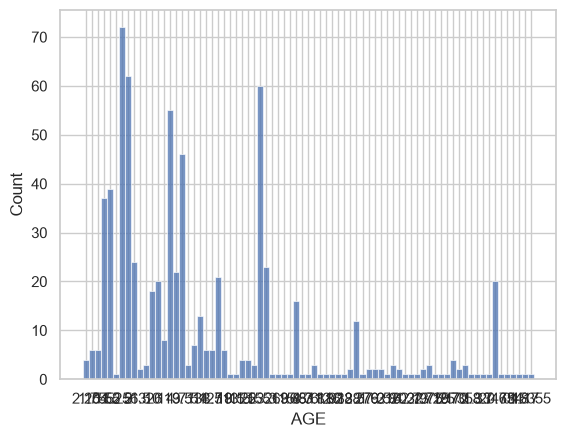

In [28]:
mortality.describe()
sns.histplot(mortality['AGE'])

## Graph Construction

Requires `networkx` (add it to `requirements.txt` and reinstall if not already present).

In [4]:
# import networkx as nx
#
# G = nx.Graph()
# G.add_edges_from(edge_list)
# nx.draw(G, with_labels=True, node_color="lightblue")

## Modeling

In [5]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# model = RandomForestClassifier(random_state=42)
# model.fit(X_train, y_train)
# preds = model.predict(X_test)
# print(classification_report(y_test, preds))